In [1]:
import pandas as pd
import numpy as np
from sklearn.cluster import DBSCAN
from sklearn.cluster import KMeans
from matplotlib import pyplot as plt

In [2]:
basic1 = pd.read_csv("./colors/blob.csv")
basic1.head()

,x,y,color
0,199.115034,72.641121,1
1,196.880523,247.744708,2
2,88.426271,233.962425,2
3,118.578789,264.044188,2
4,249.572490,260.896521,0


In [3]:
basic1['color'].unique()

array([1, 2, 0, 3], dtype=int64)

In [4]:
df1 = basic1[basic1["color"] == 0]
df2 = basic1[basic1["color"] == 1]
df3 = basic1[basic1["color"] == 2]
df4 = basic1[basic1["color"] == 3]

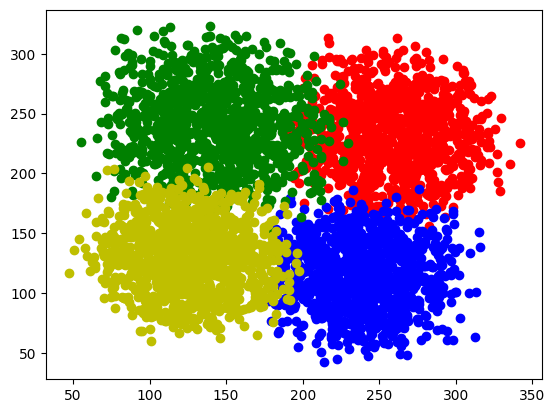

In [5]:
plt.scatter(df1["x"],df1["y"],c="r")
plt.scatter(df2["x"],df2["y"],c="b")
plt.scatter(df3["x"],df3["y"],c="g")
plt.scatter(df4["x"],df4["y"],c="y")

##### Elbow to check how much machine could organize well

c:\Users\Sakhi Larik\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
c:\Users\Sakhi Larik\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
c:\Users\Sakhi Larik\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
c:\Users\Sakhi Larik\AppData\Local\Programs\Python\Python311\Lib\si

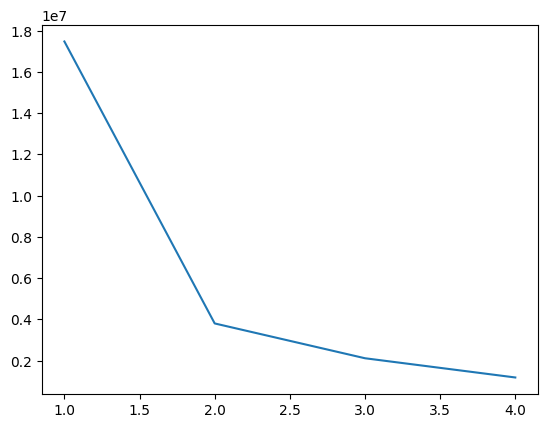

In [6]:
sse = []
for k in range(1,5):
    KM = KMeans(k)
    KM.fit(basic1[["x"]],basic1[["y"]])
    sse.append(KM.inertia_)

plt.plot(range(1,5),sse)


### KMeans

In [7]:
KM = KMeans(n_clusters=4)

In [8]:
KM.fit(basic1[["x"]],basic1[["y"]])

c:\Users\Sakhi Larik\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


KMeans(n_clusters=4)

In [9]:
clusters = KM.predict(basic1[["x"]])
np.unique(clusters)

array([0, 1, 2, 3])

In [10]:
basic1["KMeans_clusters"] = clusters

In [11]:
basic1.tail()

,x,y,color,KMeans_clusters
4081,124.085168,168.807922,3,1
4082,243.835577,216.936490,0,0
4083,226.728155,136.945680,1,0
4084,225.831882,95.884561,1,0
4085,95.551361,182.679353,3,1


In [12]:
df1 = basic1[basic1["KMeans_clusters"] == 0]
df2 = basic1[basic1["KMeans_clusters"] == 1]
df3 = basic1[basic1["KMeans_clusters"] == 2]
df4 = basic1[basic1["KMeans_clusters"] == 3]

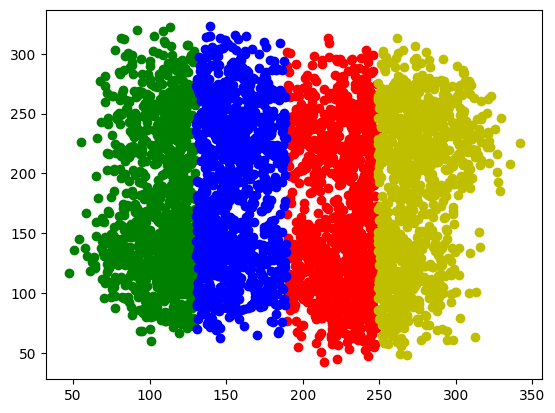

In [13]:
plt.scatter(df1["x"],df1["y"],c="r")
plt.scatter(df2["x"],df2["y"],c="g")
plt.scatter(df3["x"],df3["y"],c="y")
plt.scatter(df4["x"],df4["y"],c="b")

### DBSCAN

In [69]:
DB = DBSCAN(eps=2,min_samples=5)

In [70]:
clusters = DB.fit_predict(basic1[["x"]],basic1[["y"]])

In [71]:
np.unique(clusters)

array([-1,  0,  1,  2], dtype=int64)

In [72]:
basic1["DBSCAN_clusters"] = clusters

In [73]:
df1 = basic1[basic1["DBSCAN_clusters"] == -1]
df2 = basic1[basic1["DBSCAN_clusters"] == 0]
df3 = basic1[basic1["DBSCAN_clusters"] == 1]
df4 = basic1[basic1["DBSCAN_clusters"] == 2]

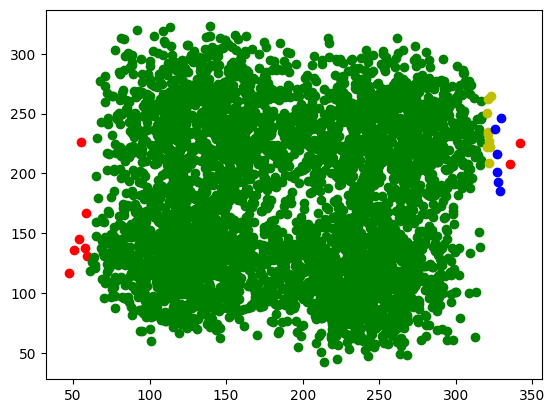

In [74]:
plt.scatter(df1["x"],df1["y"],c="r")
plt.scatter(df2["x"],df2["y"],c="g")
plt.scatter(df3["x"],df3["y"],c="y")
plt.scatter(df4["x"],df4["y"],c="b")